# 07 · Token accounting and cost: the COST layer

**FDE Academy · Accelerator track · Retrieval, RAG and Evals · Lab notebook 7 of 8**

You split one real request into its four token categories, simulate a prefix cache against the ways people break it, compute the break-even, price one grounded answer, and pull the cost levers in the order they should be pulled, measuring quality alongside.

| How to run | What it needs | Runs before | Runs after |
|---|---|---|---|
| Run All, top to bottom. Every cell executes offline in under a minute or two. | Python 3.10 or later with numpy, pandas, matplotlib and scikit-learn. `boto3` and `tiktoken` are optional and detected automatically. | Notebook 06. | Notebook 08, which multiplies every number here by the number of agent turns. |

Dollar rates in this notebook are parameters with illustrative defaults, never quotes. The cache multipliers are verified against provider documentation as of 2026-08-31 and are the structure the arithmetic rests on.

## Where this sits on the pipeline

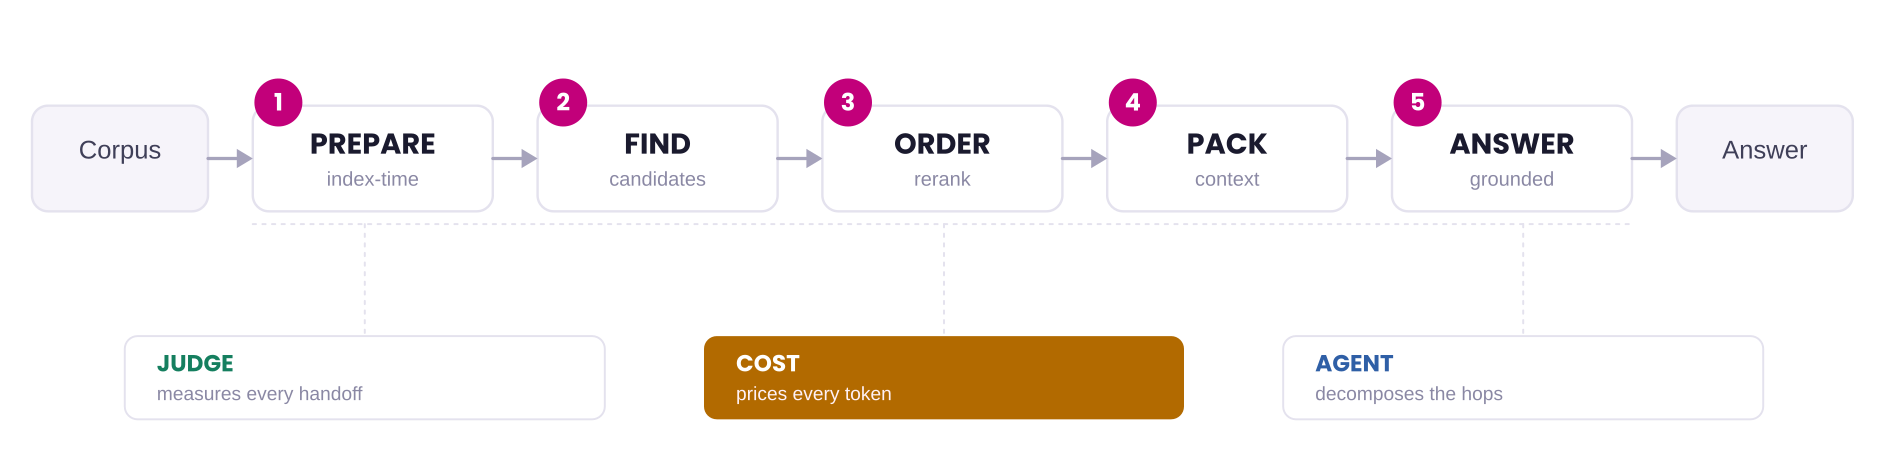

*Cost is a layer over every stage; every knob upstream moves it.*

## 1 · Four token categories on the same request

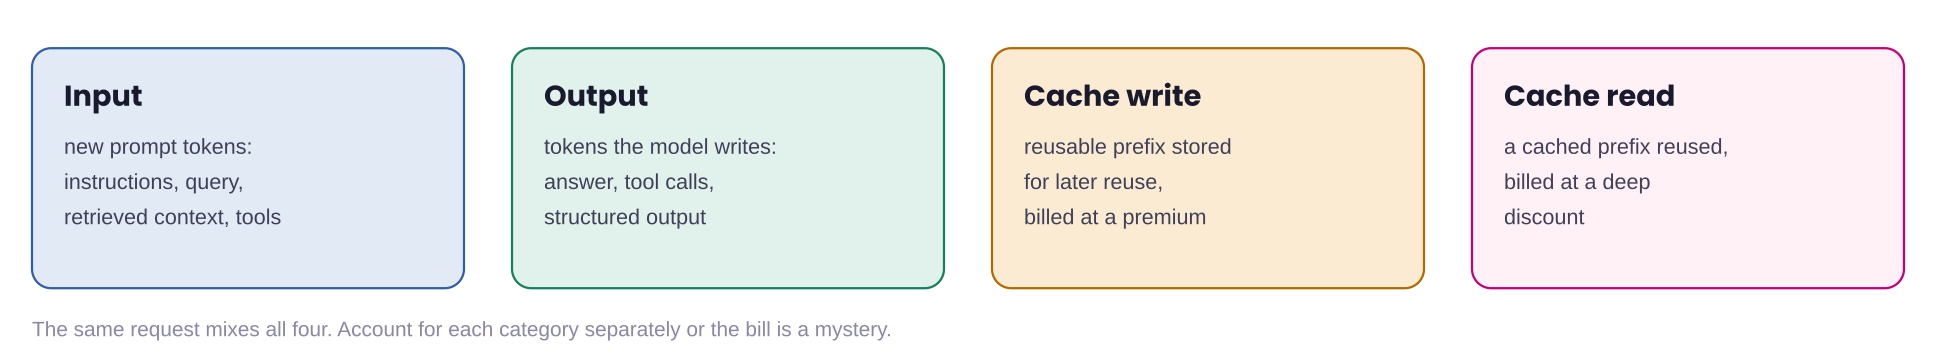

*Established billing structure for both major providers.*

In [1]:
# One-click setup. The notebook runs offline on numpy, pandas, matplotlib, scikit-learn and sqlite3.
# `ragkit` ships in the same folder as this notebook.
import sys, os
from pathlib import Path
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "ragkit").is_dir():
        sys.path.insert(0, str(p)); break
import numpy as np, pandas as pd
import ragkit as rk
from ragkit import table, verdict_style, bars, lines, decision
rk.palette.style()
pd.set_option("display.width", 160)
print("ragkit", rk.__version__, "| provider:", rk.config()["provider"], "| tokenizer:", rk.TOKENIZER)

ragkit 0.1.0 | provider: mock | tokenizer: tiktoken cl100k_base


In [2]:
store, chunks, embedder, retriever, generator, questions = rk.bootstrap(chunker="structural")
texts = {c.chunk_id: c.text for c in chunks}; meta = {c.chunk_id: {"source": store.doc(c.doc_id).source, "date": store.doc(c.doc_id).date} for c in chunks}
anchor = rk.ANCHOR
import json
TOOLS = json.dumps([{"name": "search_corpus", "description": "Retrieve evidence chunks for a query", "input_schema": {"type": "object", "properties": {"query": {"type": "string"}, "k": {"type": "integer"}}, "required": ["query"]}},
                    {"name": "grep_files", "description": "Literal pattern search over files", "input_schema": {"type": "object", "properties": {"pattern": {"type": "string"}}, "required": ["pattern"]}}], sort_keys=True)
SHOTS = "\n".join(f"Q: {q.text}\nA: {q.answer or 'INSUFFICIENT EVIDENCE.'}" for q in questions[3:6])
PREFIX = f"<system>\n{rk.SYSTEM_CONTRACT}\n</system>\n<tools>\n{TOOLS}\n</tools>\n<examples>\n{SHOTS}\n</examples>\n"
packed = rk.pack(retriever.hybrid(anchor.text, k=50), texts, evidence_cap=6000, k=8)
BODY = "\n".join(f"<evidence id=\"{c}\">{texts[c]}</evidence>" for c in packed.chunk_ids) + f"\n<question>{anchor.text}</question>"
rates = rk.Rates()
one = rk.CacheSimulator(rates).run([rk.Request(PREFIX, BODY, output_tokens=150, t=0)], caching=False)
two = rk.CacheSimulator(rates).run([rk.Request(PREFIX, BODY, output_tokens=150, t=0), rk.Request(PREFIX, BODY.replace(anchor.text, questions[1].text), output_tokens=150, t=30)], caching=True)
print(f"prefix {rk.count_tokens(PREFIX):,} tokens (contract, tools, examples) | body {rk.count_tokens(BODY):,} tokens (evidence, question) | rates: {rates.label}")
display(table(one.table(rates), "One request, no caching"))
table(two.table(rates), "Two requests thirty seconds apart, the second one a cache hit on the prefix")

prefix 299 tokens (contract, tools, examples) | body 515 tokens (evidence, question) | rates: illustrative: 3 in, 15 out, 5-minute cache


category,tokens,rate per M,dollars
uncached input,814,3.000,0.002
cache write,0,3.750,0.000
cache read,0,0.300,0.000
output,150,15.000,0.002


category,tokens,rate per M,dollars
uncached input,1028,3.000,0.003
cache write,299,3.750,0.001
cache read,299,0.300,0.000
output,300,15.000,0.004


| Category | What it is on this request | Rate, as a multiple of base input |
|---|---|---|
| Uncached input | The evidence blocks and the question, which change on every request. | 1.0x |
| Cache write | The prefix the first time it is seen inside the TTL: contract, tools, examples. | 1.25x on a 5-minute cache, 2x on a 1-hour cache (Anthropic); 1.25x (OpenAI GPT-5.6). |
| Cache read | The same prefix on the next request, byte for byte identical. | 0.1x. |
| Output | The generated answer. | The output rate, typically several times base input. |

Reading the two-request table: the second request paid a tenth of the prefix and full price for its own evidence and question. The prefix here is small because the toolkit's contract and examples are short; in production the prefix is often the largest slice of the request.

## 2 · The cache lifecycle, and the five ways people break it

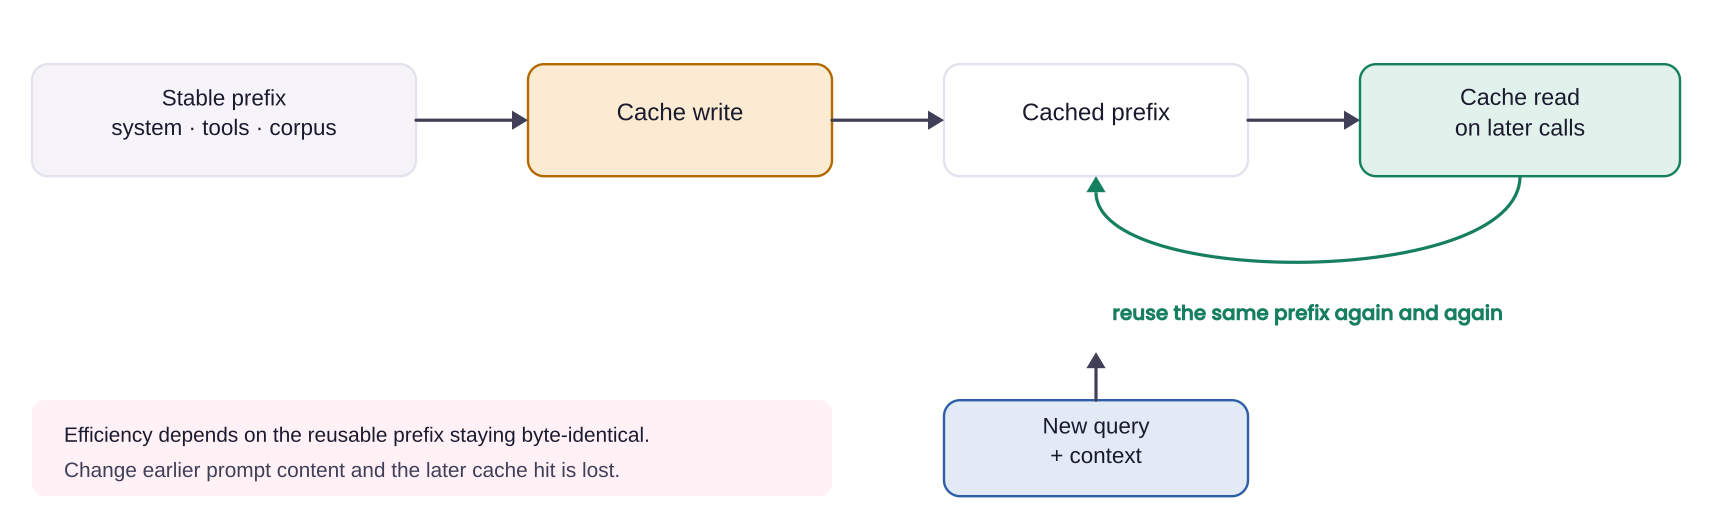

*Established. The simulator below is a prefix cache keyed on exact bytes with a TTL refreshed on hit.*

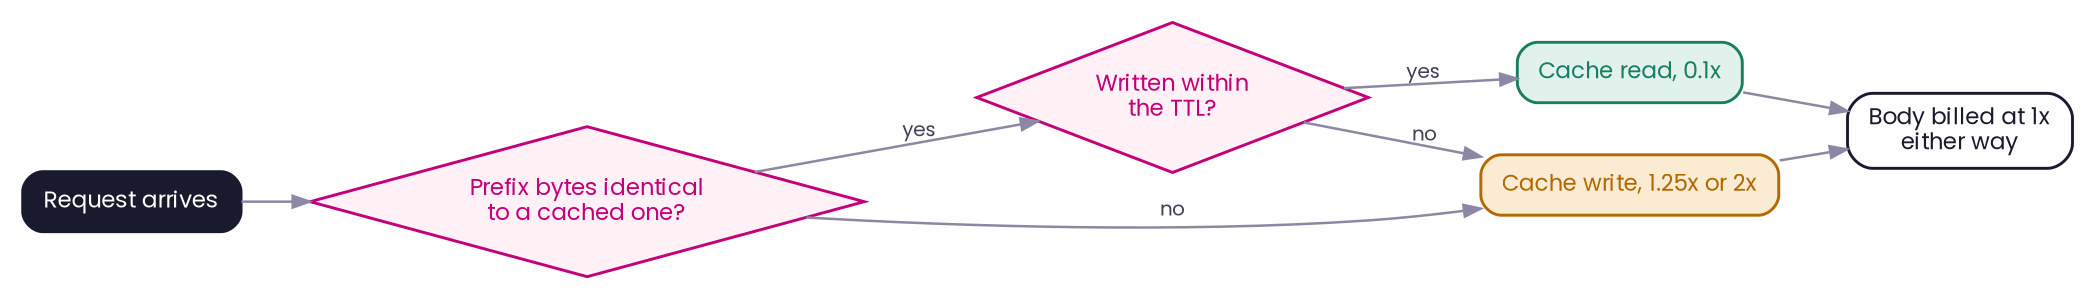

*What the simulator does per request.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    req(["Request arrives"])
    same{"Prefix bytes identical<br/>to a cached one?"}
    ttl{"Written within<br/>the TTL?"}
    hit["Cache read, 0.1x"]
    write["Cache write, 1.25x or 2x"]
    body["Body billed at 1x<br/>either way"]
    req --> same
    same -->|yes| ttl
    same -->|no| write
    ttl -->|yes| hit
    ttl -->|no| write
    hit --> body
    write --> body
    class req start
    class same dec
    class ttl dec
    class hit ok
    class write cost
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

prompt design,cache hit rate,"cost, 120 requests",cost with no caching,saving
timestamp to the second in the system prompt,0.070,0.587,0.567,-3%
request id at the front,0.000,0.591,0.564,-5%
tool schema serialised in random key order,0.000,0.600,0.571,-5%
two system-prompt variants A/B per request,0.980,0.466,0.562,+17%
"ordered by volatility, date rounded to the day",0.990,0.466,0.565,+18%


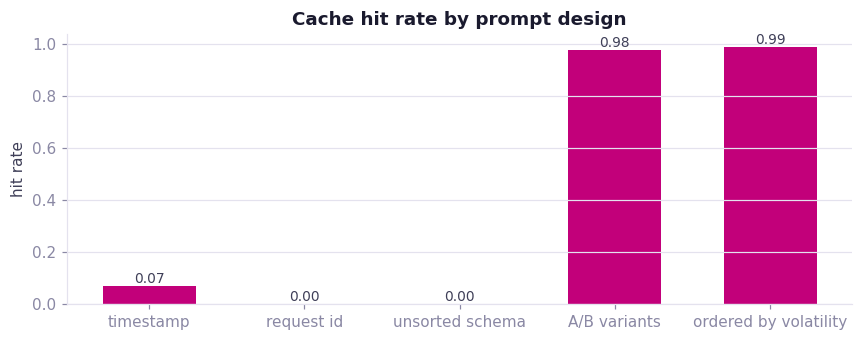

In [3]:
import datetime as dt
rng = np.random.default_rng(0)
N = 120; t = np.cumsum(rng.exponential(10, N))       # 120 requests, about one every 10 seconds
qs_cycle = [q.text for q in questions]
def requests(design):
    out = []
    for i, ti in enumerate(t):
        stamp = dt.datetime(2026, 8, 31, 14, 0, 0) + dt.timedelta(seconds=float(ti))
        body = BODY.replace(anchor.text, qs_cycle[i % len(qs_cycle)])
        if design == "timestamp to the second in the system prompt":
            prefix = f"Today is {stamp:%Y-%m-%d %H:%M:%S}.\n" + PREFIX
        elif design == "request id at the front":
            prefix = f"request-id: {i:06d}\n" + PREFIX
        elif design == "tool schema serialised in random key order":
            shuffled = []
            for tool in json.loads(TOOLS):
                keys = list(tool.keys()) + ["version", "owner"]; rng.shuffle(keys)
                shuffled.append({k: tool.get(k, "v1" if k == "version" else "platform") for k in keys})
            prefix = PREFIX.replace(TOOLS, json.dumps(shuffled))
        elif design == "two system-prompt variants A/B per request":
            prefix = PREFIX + ("\nBe concise." if rng.random() < 0.5 else "\nBe thorough.")
        else:   # ordered by volatility, date rounded to the day
            prefix = PREFIX + f"Today is {stamp:%Y-%m-%d}.\n"
        out.append(rk.Request(prefix, body, output_tokens=150, t=float(ti)))
    return out
designs = ["timestamp to the second in the system prompt", "request id at the front", "tool schema serialised in random key order", "two system-prompt variants A/B per request", "ordered by volatility, date rounded to the day"]
rows = []
for d in designs:
    bill = rk.CacheSimulator(rates).run(requests(d)); base_bill = rk.CacheSimulator(rates).run(requests(d), caching=False)
    rows.append({"prompt design": d, "cache hit rate": round(bill.hits / N, 2), "cost, 120 requests": round(bill.cost(rates), 4), "cost with no caching": round(base_bill.cost(rates), 4), "saving": f"{1 - bill.cost(rates) / base_bill.cost(rates):+.0%}"})
res = pd.DataFrame(rows)
display(table(res, f"{N} requests over about {t[-1] / 60:.0f} minutes, 5-minute TTL, illustrative rates"))
bars(["timestamp", "request id", "unsorted schema", "A/B variants", "ordered by volatility"], list(res["cache hit rate"]), "Cache hit rate by prompt design", "hit rate", fmt="{:.2f}", figsize=(8, 3.2))

| Cache killer | What the simulator showed | The fix |
|---|---|---|
| A timestamp to the second in the system prompt. | Near-zero hits: only requests inside the same second shared a prefix. | Round it to the day, or move it below the cached prefix. |
| A session or request id near the front. | Zero hits: every prefix was unique. | Put ids after the stable prefix. |
| A tool schema serialised in non-deterministic key order. | The cache fragmented into as many variants as there were orderings, and most requests missed. | Sort keys. |
| A/B testing the system prompt per request. | At this traffic level both variants stayed warm, so the hit rate held; the cost is two cache writes instead of one and, at lower traffic, two separate expiries. | Test at the tail of the prompt, or per tenant rather than per request. |
| A gap between reuses longer than the TTL. | Not in this run; the next cell shows it. | Choose the TTL by the gap between reuses, which is the decision in section 4. |

Track cache hit rate as a first-class metric next to p95 latency. A hit rate that drops overnight usually means someone edited the top of the prompt.

In [4]:
# the TTL trap: a low-traffic service whose reuses arrive just after the cache expires pays the write every time
gap_s = [60, 240, 360, 900]
rows = []
for g in gap_s:
    reqs = [rk.Request(PREFIX + "Today is 2026-08-31.\n", BODY, 150, t=i * g) for i in range(10)]
    for ttl, label in [(300, "5-minute cache, 1.25x write"), (3600, "1-hour cache, 2x write")]:
        r_ = rk.Rates(ttl_s=ttl, cache_write_mult=1.25 if ttl == 300 else 2.0)
        b = rk.CacheSimulator(r_).run(reqs); n = rk.CacheSimulator(r_).run(reqs, caching=False)
        rows.append({"gap between reuses": f"{g // 60} min", "cache": label, "hit rate": round(b.hits / 10, 2), "cost vs no caching": f"{b.cost(r_) / n.cost(r_):.2f}x"})
table(pd.DataFrame(rows), "Ten reuses of the same prefix at a fixed gap. Above 1.00x, caching costs more than it saves.")

gap between reuses,cache,hit rate,cost vs no caching
1 min,"5-minute cache, 1.25x write",0.900,0.85x
1 min,"1-hour cache, 2x write",0.900,0.86x
4 min,"5-minute cache, 1.25x write",0.900,0.85x
4 min,"1-hour cache, 2x write",0.900,0.86x
6 min,"5-minute cache, 1.25x write",0.000,1.05x
6 min,"1-hour cache, 2x write",0.900,0.86x
15 min,"5-minute cache, 1.25x write",0.000,1.05x
15 min,"1-hour cache, 2x write",0.900,0.86x


## 3 · Break-even: when the cache pays for itself

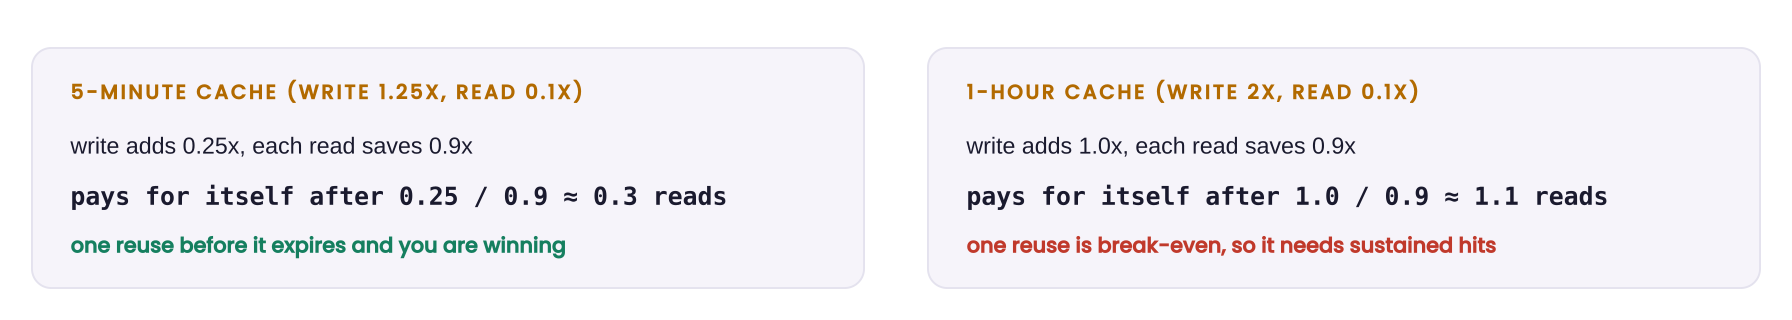

*Established arithmetic; the cell computes it.*


$$ \text{caching wins after } n \text{ sends when} \quad w + (n-1)\,r < n \quad\Longrightarrow\quad n > \frac{w - r}{1 - r} $$

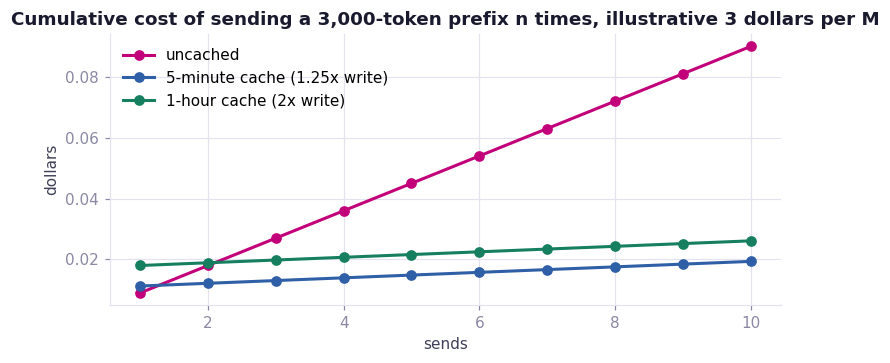

cache,break-even sends,meaning
"5-minute, write 1.25x, read 0.1x",1.280,the second send is already cheaper than not caching
"1-hour, write 2x, read 0.1x",2.110,needs three sends; a prefix reused once on this cache costs more than no cache


In [5]:
prefix_tokens = 3000
n, unc, c5 = rk.cumulative_cost_curve(prefix_tokens, 10, rk.Rates(cache_write_mult=1.25))
_, _, c60 = rk.cumulative_cost_curve(prefix_tokens, 10, rk.Rates(cache_write_mult=2.0))
lines(n, {"uncached": unc, "5-minute cache (1.25x write)": c5, "1-hour cache (2x write)": c60}, f"Cumulative cost of sending a {prefix_tokens:,}-token prefix n times, illustrative 3 dollars per M", "sends", "dollars")
table(pd.DataFrame([{"cache": "5-minute, write 1.25x, read 0.1x", "break-even sends": round(rk.breakeven_reads(1.25, 0.1), 2), "meaning": "the second send is already cheaper than not caching"},
                    {"cache": "1-hour, write 2x, read 0.1x", "break-even sends": round(rk.breakeven_reads(2.0, 0.1), 2), "meaning": "needs three sends; a prefix reused once on this cache costs more than no cache"}]),
      "Break-even in sends, from the formula above")

| If | Then | Because |
|---|---|---|
| The prefix is reused at least twice within 5 minutes. | Cache it on the short TTL. | Break-even is under two sends. |
| Reuses arrive in bursts more than 5 minutes apart but inside an hour. | Cache it on the long TTL, and check the arithmetic at three sends. | The 2x write needs three sends to pay back. |
| The prefix is reused once or not at all. | Do not cache it; on some providers caching is automatic, so structure the prompt so the reusable part is what gets cached. | You would pay the write premium for nothing. |

## 4 · The multipliers are the structure; the dollar rates are a parameter

Verified against provider documentation on 2026-08-31. Re-check before quoting either to a client, since rates moved twice in the two months before that date.

In [6]:
display(table(pd.DataFrame(rk.PROVIDER_MULTIPLIERS), "Cache multipliers, verified 2026-08-31"))
RATES = rk.Rates(input=3.0, output=15.0, cache_write_mult=1.25, cache_read_mult=0.10, ttl_s=300, label="your rates go here")
TTL_TREE = [
    {"q": "Is the typical gap between reuses of this prefix under 5 minutes?", "test": lambda f: f["gap_s"] < 300, "yes": "5-minute cache: the write pays back on the second send", "no": None, "show": lambda f: f"gap={f['gap_s']} s"},
    {"q": "Is it under an hour, with at least three sends inside it?", "test": lambda f: f["gap_s"] < 3600 and f["sends_per_hour"] >= 3, "yes": "1-hour cache (or the provider's 30-minute floor): the 2x write pays back on the third send", "no": "do not rely on the cache for this prefix; shrink it or restructure the prompt", "show": lambda f: f"sends per hour={f['sends_per_hour']}"},
]
display(table(decision(TTL_TREE, {"gap_s": 12, "sends_per_hour": 300}), "A busy assistant, a request every 12 seconds"))
table(decision(TTL_TREE, {"gap_s": 900, "sends_per_hour": 4}), "A low-traffic internal tool, a request every 15 minutes")

provider,cache_write_mult,cache_read_mult,ttl,note
"Anthropic, 5-minute cache",1.250,0.100,"5 min, refreshed on hit",cache_control on blocks or automatic; up to 4 breakpoints
"Anthropic, 1-hour cache",2.000,0.100,1 hour,pays back after two reads instead of one
OpenAI GPT-5.6 and later,1.250,0.100,30 min minimum,explicit breakpoints via prompt_cache_breakpoint; prompt_cache_key recommended


question,measured,answer
Is the typical gap between reuses of this prefix under 5 minutes?,gap=12 s,yes
Outcome,,5-minute cache: the write pays back on the second send


question,measured,answer
Is the typical gap between reuses of this prefix under 5 minutes?,gap=900 s,no
"Is it under an hour, with at least three sends inside it?",sends per hour=4,yes
Outcome,,1-hour cache (or the provider's 30-minute floor): the 2x write pays back on the third send


| Difference | Anthropic | OpenAI, GPT-5.6 and later |
|---|---|---|
| How caching is declared | `cache_control` on content blocks, or automatic; up to four breakpoints. | Explicit breakpoints via `prompt_cache_breakpoint`, with `prompt_cache_key` recommended for routing. |
| Write premium | 1.25x for the 5-minute cache, 2x for the 1-hour cache. | 1.25x. |
| Read rate | 0.1x. | 0.1x. |
| Lifetime | 5 minutes, refreshed on hit; or 1 hour. | 30-minute minimum. |
| What both share | The cache is a prefix match on exact bytes, so order by volatility and keep the front stable. | The same. |

## 5 · What one grounded answer costs

The line items below use the advanced-track deck's illustrative shape (a 3,000-token cached prefix, k=8 chunks of about 550 tokens, a 450-token answer) next to this corpus's measured tokens, so the proportions can be compared.

line item,"illustrative request, dollars","this corpus, measured tokens, dollars"
prefix,0.00090,0.00009
evidence,0.01320,0.00104
question,0.00060,0.00007
output,0.00675,0.00225
rerank,0.00040,0.00000
embed,0.00005,0.00000
total,0.02190,0.00345


illustrative request at 200,000 queries a month: 4,380 dollars cached, 6,000 uncached; caching the prefix removes about 27% of the bill


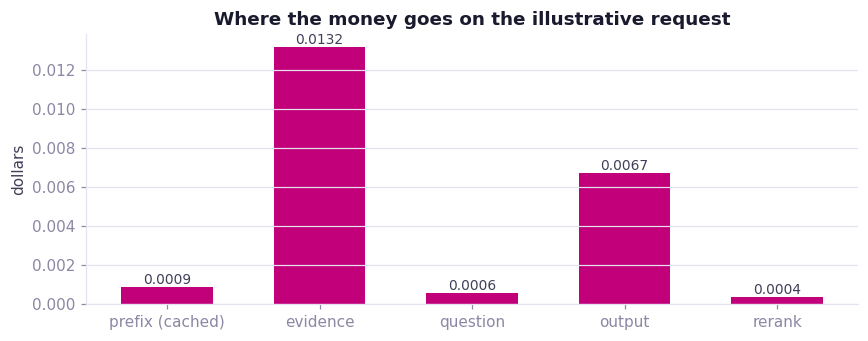

In [7]:
deck_items = rk.query_cost(prefix_tokens=3000, evidence_tokens=8 * 550, question_tokens=200, output_tokens=450, rates=RATES, cached=True, rerank_dollars=0.0004, embed_dollars=0.00005)
deck_uncached = rk.query_cost(3000, 8 * 550, 200, 450, RATES, cached=False, rerank_dollars=0.0004, embed_dollars=0.00005)
measured_ev = int(rk.run_benchmark(rk.RunConfig("k8", mode="hybrid", k=8), retriever, generator, questions, chunks)["evidence_tokens"].mean())
here = rk.query_cost(prefix_tokens=rk.count_tokens(PREFIX), evidence_tokens=measured_ev, question_tokens=rk.count_tokens(anchor.text), output_tokens=150, rates=RATES, cached=True)
rows = [{"line item": k, "illustrative request, dollars": round(deck_items[k], 5), "this corpus, measured tokens, dollars": round(here[k], 5)} for k in ["prefix", "evidence", "question", "output", "rerank", "embed", "total"]]
display(table(pd.DataFrame(rows), f"Per answered query at {RATES.label}", precision=5))
monthly = 200_000
print(f"illustrative request at {monthly:,} queries a month: {deck_items['total'] * monthly:,.0f} dollars cached, {deck_uncached['total'] * monthly:,.0f} uncached; caching the prefix removes about {1 - deck_items['total'] / deck_uncached['total']:.0%} of the bill")
bars(["prefix (cached)", "evidence", "question", "output", "rerank"], [deck_items[k] for k in ["prefix", "evidence", "question", "output", "rerank"]], "Where the money goes on the illustrative request", "dollars", fmt="{:.4f}", figsize=(8, 3.2))

| Reading the table | The consequence |
|---|---|
| Evidence is the largest input line on the illustrative request, and output the largest single line. | The two levers with the most leverage are k, after proving full-chain recall holds, and a terse output contract. |
| The cached prefix costs a tenth of what it would uncached. | Caching is an afternoon of work that removes about a quarter of the illustrative bill. |
| Reranking and embedding are small line items. | Dropping the reranker to save money is the worst trade on the list, as section 6 measures. |

## 6 · The cost levers, pulled in the order you should pull them

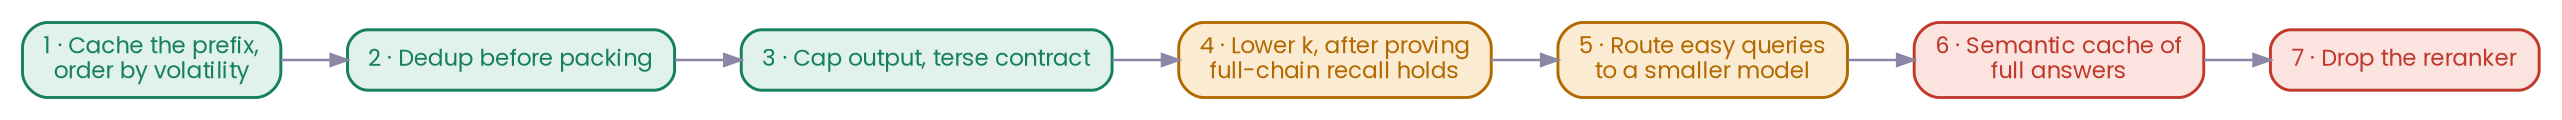

*From the advanced-track deck. Green levers are free in quality; amber ones are trades you measure; red ones are trades you declare. The cell pulls the first five on this benchmark.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    l1["1 · Cache the prefix,<br/>order by volatility"]
    l2["2 · Dedup before packing"]
    l3["3 · Cap output, terse contract"]
    l4["4 · Lower k, after proving<br/>full-chain recall holds"]
    l5["5 · Route easy queries<br/>to a smaller model"]
    l6["6 · Semantic cache of<br/>full answers"]
    l7["7 · Drop the reranker"]
    l1 --> l2
    l2 --> l3
    l3 --> l4
    l4 --> l5
    l5 --> l6
    l6 --> l7
    class l1 ok
    class l2 ok
    class l3 ok
    class l4 cost
    class l5 cost
    class l6 fail
    class l7 fail
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

lever,dollars per query,full_chain@k,correct,evidence tokens,saving vs start
"start: k=10, no cache, 450-token answers",0.00902,0.88900,0.91700,427,+0%
1 · cache the prefix,0.00821,0.88900,0.91700,427,+9%
2 · dedup before packing,0.00821,0.88900,0.91700,427,+9%
3 · cap output at 150 tokens,0.00371,0.88900,0.91700,427,+59%
4 · lower k to 8 (check recall),0.00347,0.77800,0.83300,348,+62%
5 · route easy types to a small model,0.00114,0.88900,0.91700,427,+87%


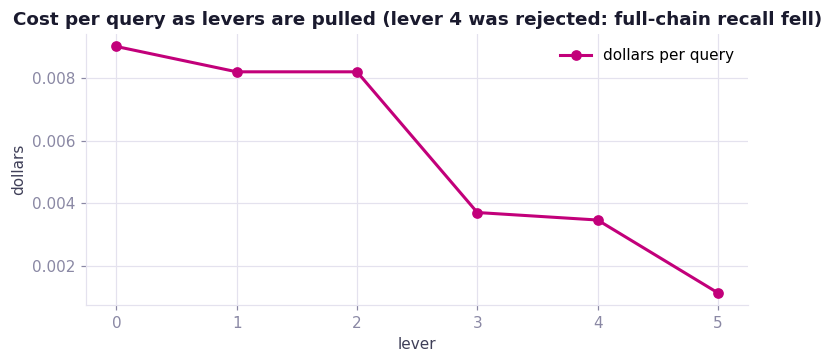

In [8]:
def price_run(df, cached, output_tokens, small_model_share=0.0):
    small = rk.Rates(input=0.2, output=1.2)     # illustrative small-model rate
    cost = []
    for _, r in df.iterrows():
        easy = small_model_share > 0 and r["type"] in ("null", "comparison", "temporal")
        rt = small if easy else RATES
        cost.append(rk.query_cost(rk.count_tokens(PREFIX), int(r["evidence_tokens"]), 30, output_tokens, rt, cached=cached)["total"])
    return float(np.mean(cost))
steps = []
def step(name, cfg, cached, out_tok, share=0.0):
    df = rk.run_benchmark(cfg, retriever, generator, questions, chunks); s = rk.summarize(df)
    steps.append({"lever": name, "dollars per query": round(price_run(df, cached, out_tok, share), 5), "full_chain@k": s["full_chain@k"], "correct": s["correct"], "evidence tokens": round(s["evidence_tokens"])})
step("start: k=10, no cache, 450-token answers", rk.RunConfig("s0", mode="hybrid", k=10), cached=False, out_tok=450)
step("1 · cache the prefix", rk.RunConfig("s1", mode="hybrid", k=10), cached=True, out_tok=450)
step("2 · dedup before packing", rk.RunConfig("s2", mode="hybrid", k=10, dedup_jaccard=0.7), cached=True, out_tok=450)
step("3 · cap output at 150 tokens", rk.RunConfig("s3", mode="hybrid", k=10, dedup_jaccard=0.7), cached=True, out_tok=150)
step("4 · lower k to 8 (check recall)", rk.RunConfig("s4", mode="hybrid", k=8, dedup_jaccard=0.7), cached=True, out_tok=150)
step("5 · route easy types to a small model", rk.RunConfig("s5", mode="hybrid", k=10, dedup_jaccard=0.7), cached=True, out_tok=150, share=1.0)
lev = pd.DataFrame(steps); lev["saving vs start"] = [f"{1 - c / steps[0]['dollars per query']:+.0%}" for c in lev["dollars per query"]]
display(table(lev, "Each lever on this benchmark, cost and quality side by side", precision=5))
lines(list(range(len(steps))), {"dollars per query": list(lev["dollars per query"])}, "Cost per query as levers are pulled (lever 4 was rejected: full-chain recall fell)", "lever", "dollars")

| Lever | What it cost in quality here | The rule it illustrates |
|---|---|---|
| 1 · Cache the prefix | Nothing. Here it saved about nine percent because the toolkit's prefix is only about 300 tokens; on the illustrative 3,000-token prefix it is the largest single cut. | Free, and it scales with the size of the stable prefix. |
| 2 · Dedup | Nothing, and it saved nothing here because this corpus carries no duplicates; on the syndicated corpus of notebook 05 it recovered a quarter of a slot per question. | Duplicates are distractors, so this lever improves quality where duplicates exist. |
| 3 · Cap output | Nothing, if the contract is well specified. | Output is the most expensive token; a terse schema is a cost feature. |
| 4 · Lower k from 10 to 8 | Full-chain recall fell from 0.89 to 0.78. Rejected. | Lower k only after proving full-chain recall holds, and measure the tail, not the mean. |
| 5 · Route easy types to a small model | Nothing on this simulator; a real router is a second system that needs its own evaluation. | The saving is real and so is the new failure surface. |
| 6 · Semantic cache of full answers | Not pulled. | A near-miss cache hit serves a confidently wrong answer to a different question. |
| 7 · Drop the reranker | Not pulled; the reranker is a small line item and, in notebook 04, quality is where it matters. | The worst trade on the list: large quality loss for a trivial saving. |

## 7 · Index-side money is spent once; query-side money is spent forever

The cell prices the two sides with parameters. Anthropic reports contextual enrichment at about one dollar per million document tokens when the document prefix is cached (verified against the contextual retrieval write-up); the embedding rate is an illustrative parameter.

In [9]:
chunks_in_corpus, tokens_per_chunk = 2_000_000, 400
corpus_tokens = chunks_in_corpus * tokens_per_chunk
EMBED_PER_M, CONTEXTUALISE_PER_M = 0.02, 1.02      # illustrative embed rate; contextualisation with caching per the write-up
index_side = {"embed the corpus once": corpus_tokens / 1e6 * EMBED_PER_M, "contextualise every chunk once, cached prefix": corpus_tokens / 1e6 * CONTEXTUALISE_PER_M}
query_side_saving_per_query = (10 - 8) * 550 * RATES.input / 1e6     # saving from k=10 to k=8 at 550 tokens a chunk
rows = [{"side": "index, one-off", "item": k, "dollars": round(v, 0)} for k, v in index_side.items()]
rows.append({"side": "query, recurring", "item": f"saving from k=10 to k=8, per query", "dollars": round(query_side_saving_per_query, 5)})
rows.append({"side": "query, recurring", "item": "the same saving over 200,000 queries a month", "dollars": round(query_side_saving_per_query * 200_000, 0)})
table(pd.DataFrame(rows), f"A {chunks_in_corpus:,}-chunk corpus of {corpus_tokens / 1e6:,.0f} million tokens, illustrative rates")

side,item,dollars
"index, one-off",embed the corpus once,16.000
"index, one-off","contextualise every chunk once, cached prefix",816.000
"query, recurring","saving from k=10 to k=8, per query",0.003
"query, recurring","the same saving over 200,000 queries a month",660.000


| If | Then | Because |
|---|---|---|
| A quality problem can be fixed at index time (contextualisation, better chunking, a lexical index). | Spend there first. | It is paid once, and it lifts every query afterwards. |
| The same problem is being attacked by raising k. | Stop and price it. | k is paid on every query, forever, and the middle of the context is where the extra chunks land. |
| The index-side fix costs on the order of a thousand dollars and the query-side saving is a few hundred a month. | The index-side fix wins inside a quarter and improves quality rather than trading it. | Recurring cost compounds; one-off cost does not. |

## Failure points in this layer

| Failure | What you saw | The fix |
|---|---|---|
| Cache miss by design | A timestamp or a request id at the front of the prompt gave a zero hit rate. | Order by volatility; round dates; sort schema keys. |
| The TTL trap | Reuses arriving after expiry paid the write every time and cost more than no caching. | Choose the TTL by the gap between reuses. |
| Spending recall to save tokens | Lever 4 cut full-chain recall from 0.89 to 0.78. | Prove recall holds before lowering k; measure the tail. |
| A second system nobody evaluates | Lever 5's router. | Evaluate the router on the same benchmark and slice by route. |
| The wrong lever first | Dropping the reranker saves about two percent and costs quality. | Pull the free levers first, declare the trades. |

## What to carry out of this notebook

| # | The line worth remembering |
|---|---|
| 1 | One request has four token categories at four rates; the prefix is the cheap one only if it is byte-identical and inside the TTL. |
| 2 | The prompt ordered by volatility is a five-minute change that often halves input spend; a timestamp at the front undoes it. |
| 3 | Break-even is arithmetic: the 5-minute cache pays back on the second send, the 1-hour cache on the third, and a once-used prefix on the long cache costs more than no cache. |
| 4 | Price one answer as line items and bring the table to the client; it turns an argument about whether AI is expensive into a discussion of which line to cut. |
| 5 | Pull the free levers first, measure the trades, and never drop the reranker to save two percent. |
| 6 | Index-side money is spent once; query-side money is spent on every request, which is why contextualisation beats raising k. |

**Next: 08 · Agentic search and the end-to-end build.** Every number here is per generation. The agentic loop multiplies the pre-generation cost by the number of turns and adds a generation per turn, and notebook 08 measures that multiplier before it lets the loop earn its place, then runs the FDE Lab build brief end to end.

## Interview corner

| Question an interviewer may ask | What a strong answer does | Red flag |
|---|---|---|
| Agentic search costs 0.90 a query on hard questions and finance wants 0.15. What do you change, and what do you refuse? | Pulls caching, dedup, output caps and routing first, escalates to the loop only on a failed sufficiency check, and refuses to drop the reranker or lower k below proven recall. | Cuts k and the reranker first. |
| Your cache hit rate dropped from 80 percent to 5 percent overnight. What happened? | Suspects an edit at the top of the prompt, a timestamp, an id, or unsorted schema keys, and checks the prefix diff before anything else. | Blames the provider. |
| Should we cache on the 1-hour TTL to be safe? | Asks for the gap between reuses and does the three-send arithmetic. | Says longer is safer. |